# Cliff walking: training

Train Q-learning and SARSA independently, then inspect their saved plots and optional recordings. Parameters are editable below. Training starts only when `RUN_TRAINING=True`; running this notebook with its default flag creates no experiment artifacts. See [the section guide](README.md) for the task and output conventions.

In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import Image, Markdown, Video, display
from rl_project.runtime import video_sort_key
from rl_project.discrete import validate_algorithms
ALGORITHM_LABELS = {"qlearning": "Q-learning", "sarsa": "SARSA"}
from Grid_cliff.grid_cliff_env import RandomCliffWalkingEnv
from rl_project.tabular import TabularAgent
from Grid_cliff.grid_cliff_algorithms import plot_comparison
from rl_project.runtime import Run

## Configuration

The canonical 5×16 map has a cliff between the start and goal. Falling gives −100 and returns to the start without terminating; reaching the goal terminates. The 200-step cutoff applies even on a fall and retains the value bootstrap. Actions are 0=up, 1=right, 2=down, 3=left.

`config.json` is written automatically inside each new run as a snapshot of the settings used. Edit this notebook, not that saved snapshot. Shortening the episode budget does not automatically accelerate the exploration schedule.

In [3]:
ALGORITHMS = ("qlearning", "sarsa")  # Select both, or e.g. ("sarsa",).
RUN_TRAINING = True
SEED = 0
NUM_EPISODES = 5000  # Budget for each selected algorithm.
MAX_ENV_STEPS = None  # Optional per-algorithm step budget; use NUM_EPISODES=None for steps only.
OUTPUT_ROOT = ROOT / "artifacts"
RECORD_EVERY = 500
LOG_EVERY = 500
SHOW_PROGRESS = True
COMPARISON_WINDOW = 100

# One common task for both algorithms.
ENV_KWARGS = {
    "layout": "canonical",
    "max_steps": 200,
    "map_seed": 34,  # Used only with layout="random"; the map then stays fixed.
    "n_cliffs": 12,  # Used only with layout="random".
    "render_mode": None,
}

# Independent algorithm settings: changing one does not change the other.
AGENT_KWARGS = {
    "qlearning": {
        "learning_rate": .1,
        "discount_factor": .99,
        "initial_epsilon": 1.,
        "epsilon_decay": .9 / 3000,
        "final_epsilon": .1,
    },
    "sarsa": {
        "learning_rate": .1,
        "discount_factor": .99,
        "initial_epsilon": 1.,
        "epsilon_decay": .9 / 3000,
        "final_epsilon": .1,
    },
}

## Train

Each selected algorithm gets a fresh agent and a separate run directory. Checkpoints and incremental CSV metrics are saved before plotting. Q-learning uses a greedy backup; SARSA executes the same next action that was sampled for its backup.

The live total progress bar stays below summaries of each `LOG_EVERY` completed episodes, including a final partial block. Summary and recording labels start at episode 0; the total bar and CSV count completed episodes from 1.

In [4]:
agents = {}
results = {}
selected_algorithms = validate_algorithms(ALGORITHMS)
if RUN_TRAINING:
    for algorithm in selected_algorithms:
        display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} training"))
        env = RandomCliffWalkingEnv(**ENV_KWARGS)
        try:
            agent = TabularAgent(env, seed=SEED, environment="cliff", **AGENT_KWARGS[algorithm])
            result = agent.train(
                NUM_EPISODES, algorithm=algorithm, max_env_steps=MAX_ENV_STEPS,
                output_root=OUTPUT_ROOT, record_every=RECORD_EVERY,
                log_every=LOG_EVERY, show_progress=SHOW_PROGRESS,
            )
            agents[algorithm] = agent
            results[algorithm] = result
            print(f"Saved run: {result.run_dir}")
        finally:
            env.close()
else:
    print("Training not run. Set RUN_TRAINING=True to start fresh runs; no checkpoint was loaded.")

### Q-learning training

c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Saved run: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\qlearning\20260915T145107708840Z_seed0_630db017


### SARSA training

Saved run: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\sarsa\20260915T145132670752Z_seed0_df131c78


## Inspect plots and recordings

Reward bands show rolling mean ± two rolling standard deviations within one run. Outcomes show rolling success rate; binary success/collision indicators are omitted. TD error and epsilon are learning diagnostics.

With `RECORD_EVERY=500`, separate greedy demonstrations run after training episodes 0, 500, 1000, and so on, producing `episode_0.mp4`, `episode_500.mp4`, etc. Episode 0 is the first completed training episode. Videos are capped at 300 frames and 800 pixels wide; the demonstration still runs to the actual episode boundary.

### Q-learning outputs

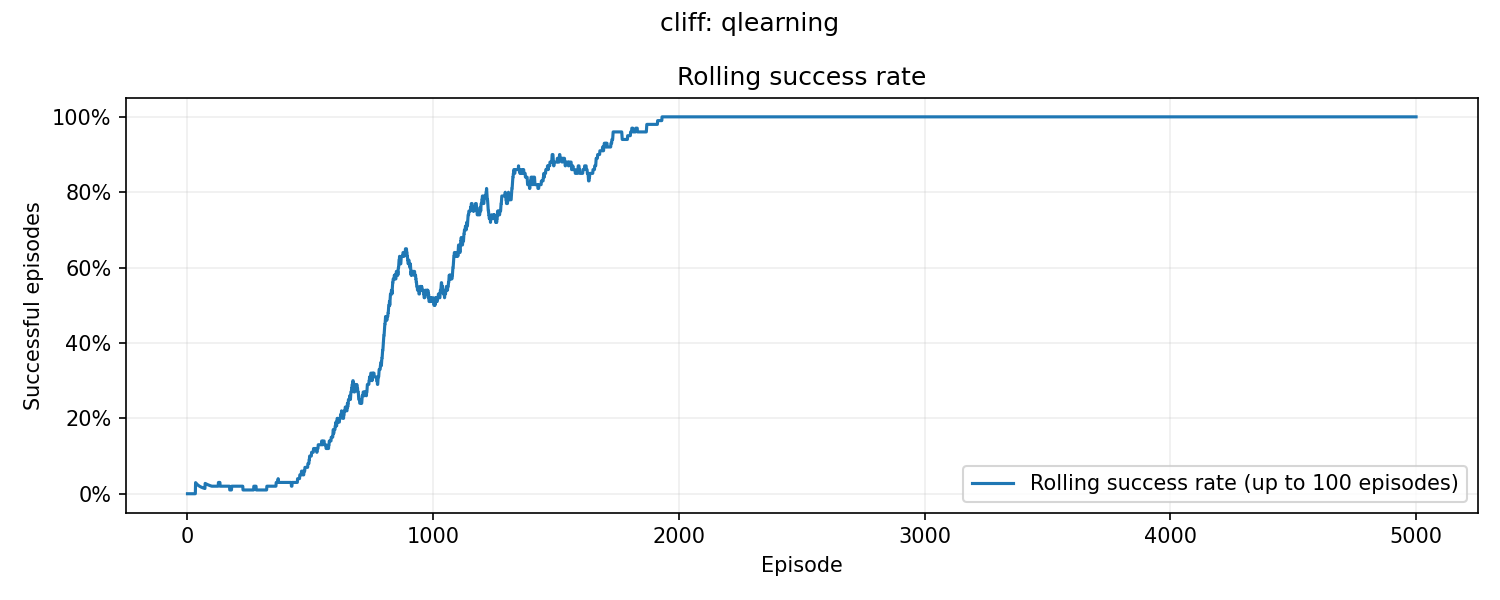

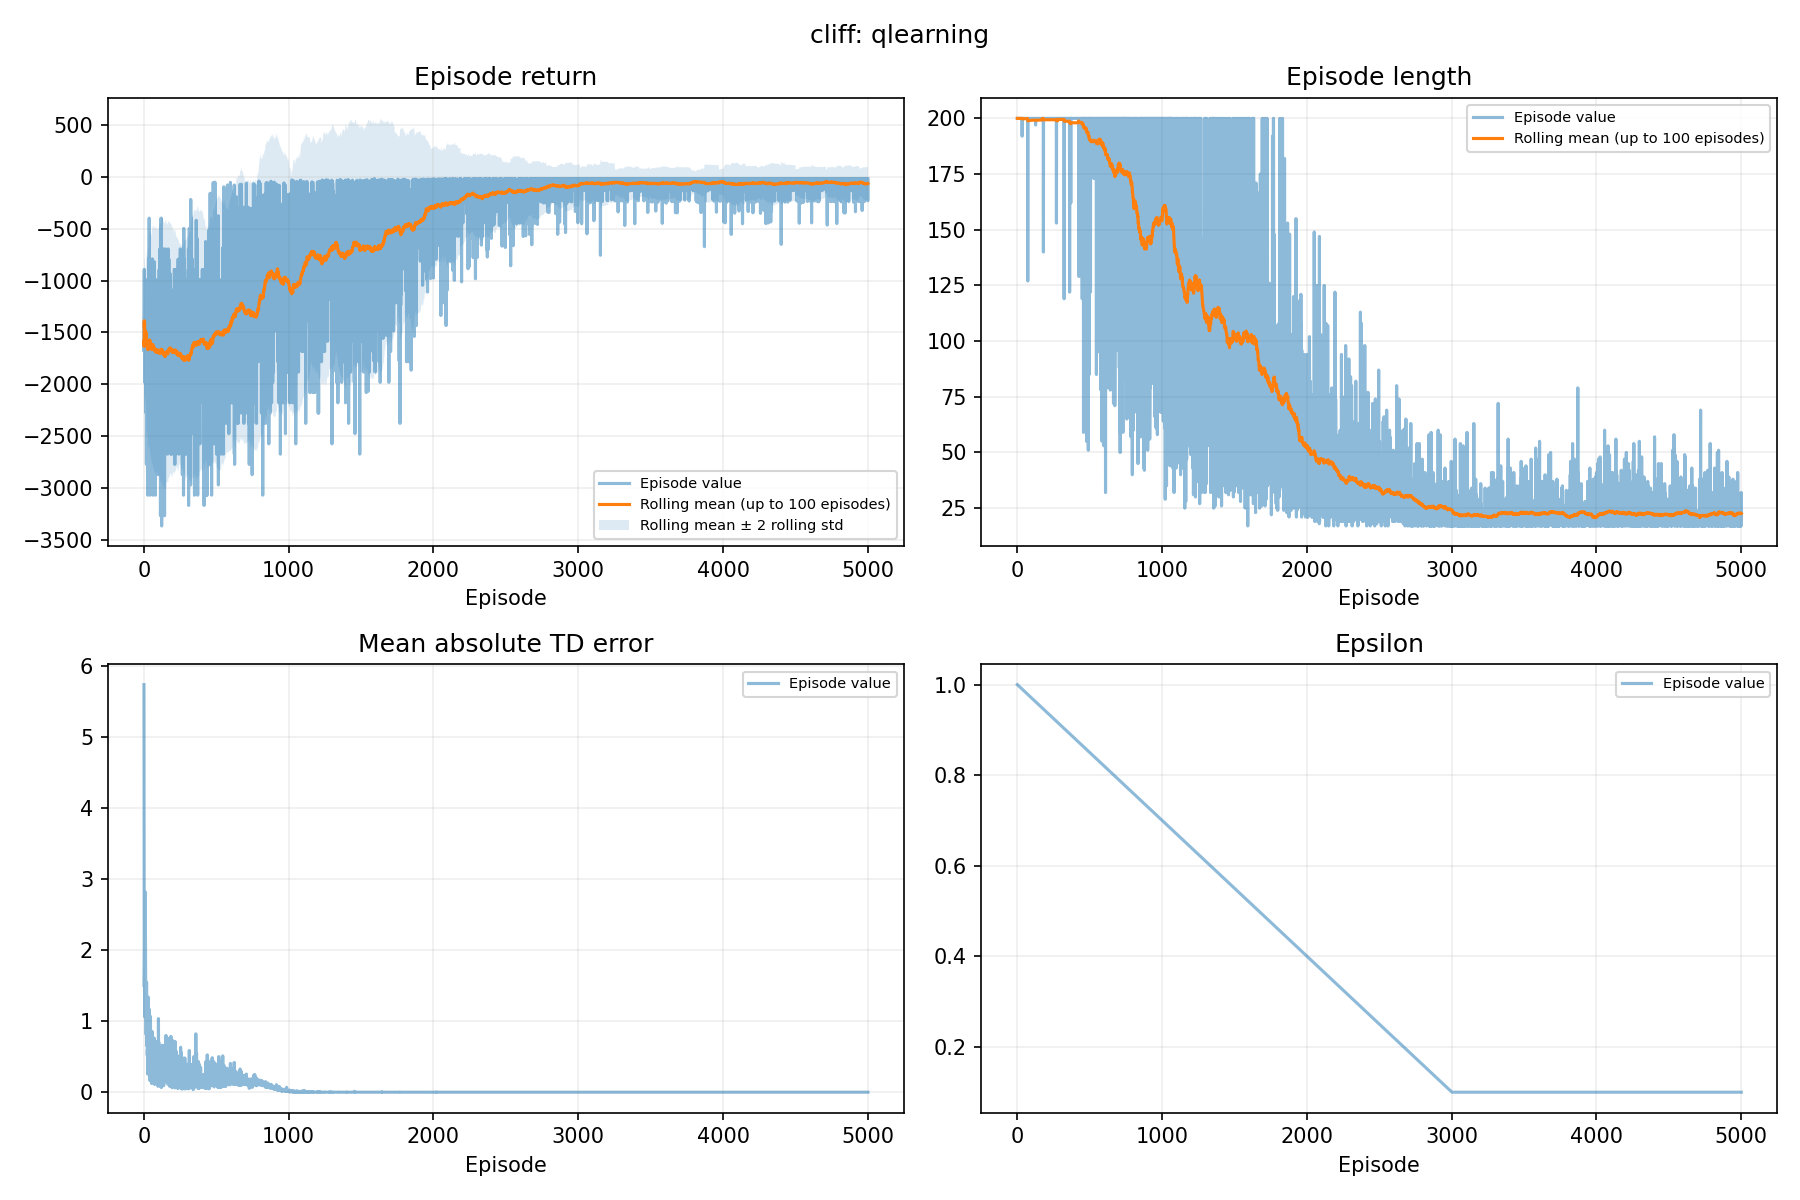

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

...

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

### SARSA outputs

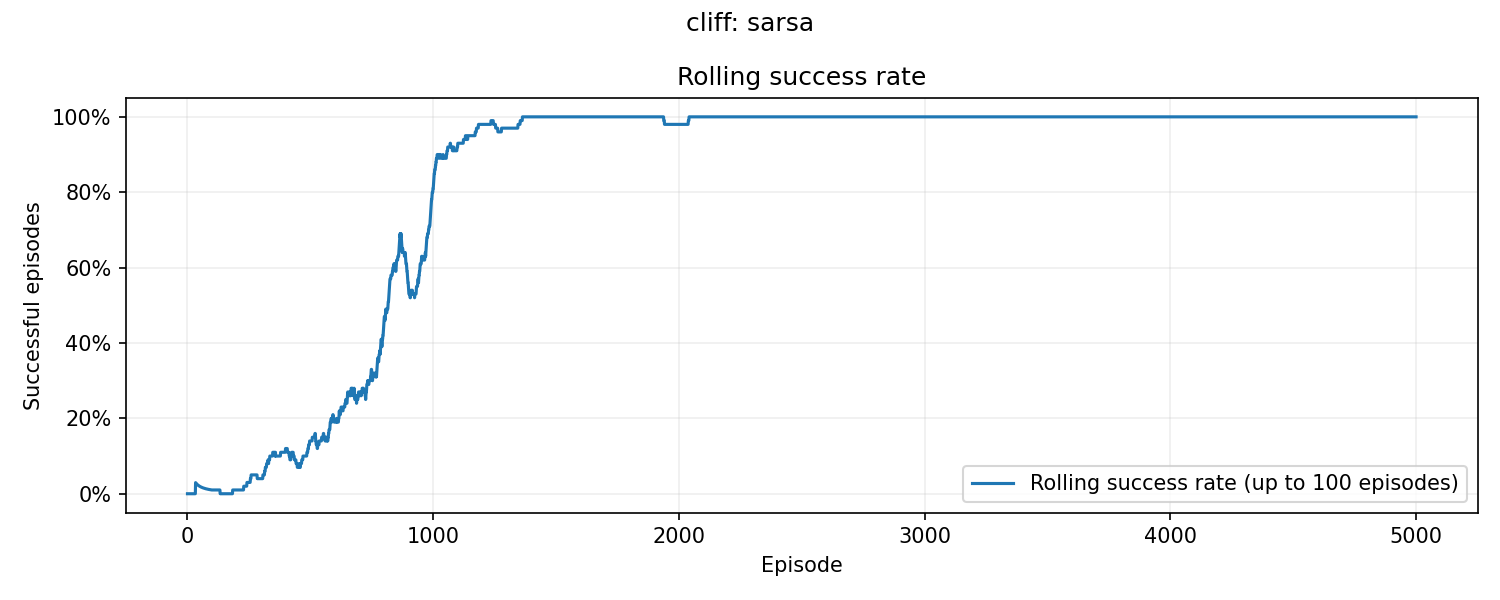

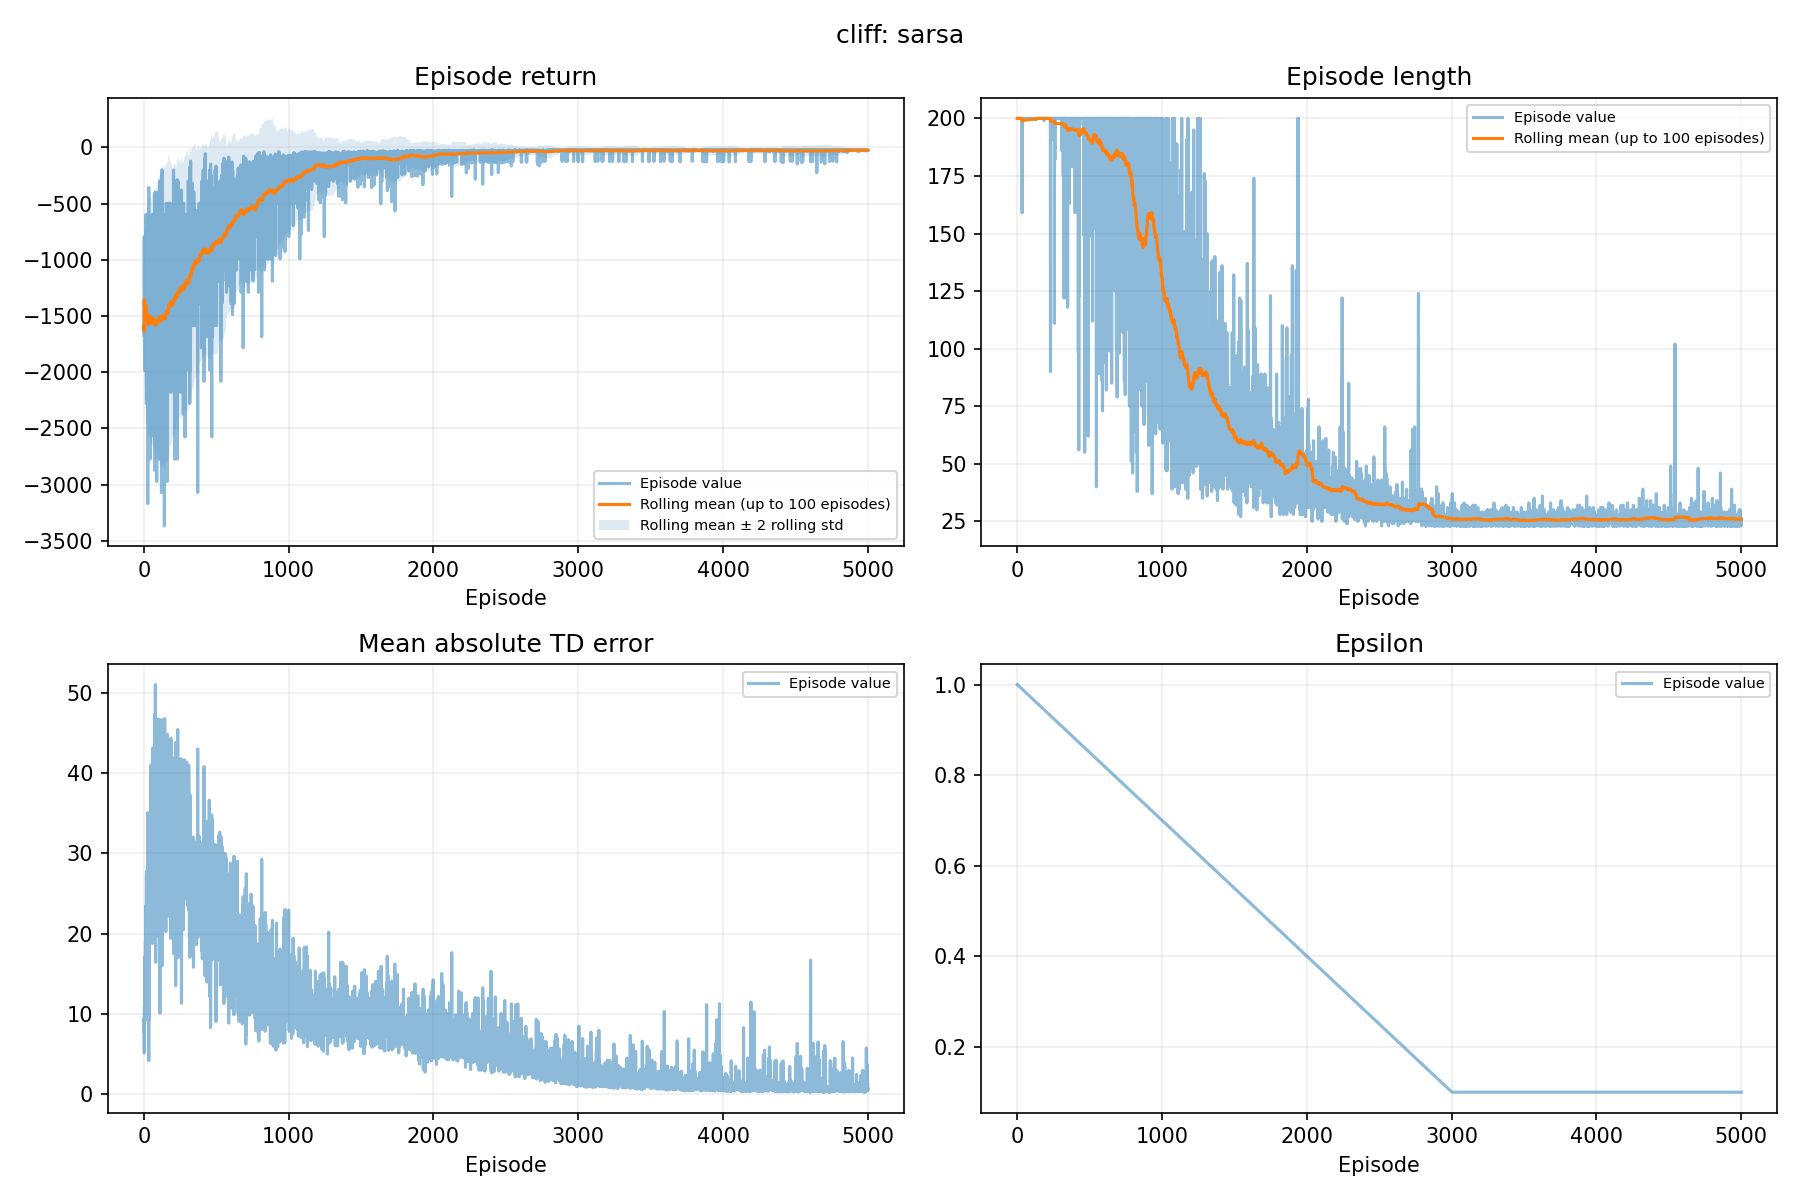

**episode_0.mp4**

**episode_500.mp4**

**episode_1000.mp4**

**episode_1500.mp4**

**episode_2000.mp4**

**episode_2500.mp4**

**episode_3000.mp4**

**episode_3500.mp4**

**episode_4000.mp4**

**episode_4500.mp4**

In [5]:
for algorithm, result in results.items():
    display(Markdown(f"### {ALGORITHM_LABELS[algorithm]} outputs"))
    for path in sorted((result.run_dir / "plots").glob("*.png")):
        display(Image(filename=str(path)))
    for path in sorted((result.run_dir / "videos/training").glob("*.mp4"), key=video_sort_key):
        display(Markdown(f"**{path.name}**"))
        display(Video(filename=str(path), embed=True))

## Q-learning versus SARSA during training

This comparison is created only when both algorithms completed in this execution. SARSA incorporates the consequences of future exploration into its backup and can favor a safer route. Q-learning evaluates greedy continuation, which can favor a short route near the cliff. A difference in training return under exploration is distinct from performance in the greedy evaluation notebook.

The comparison plots rolling return, goal-completion rate and episode length. It records the source run paths and the configured smoothing window.

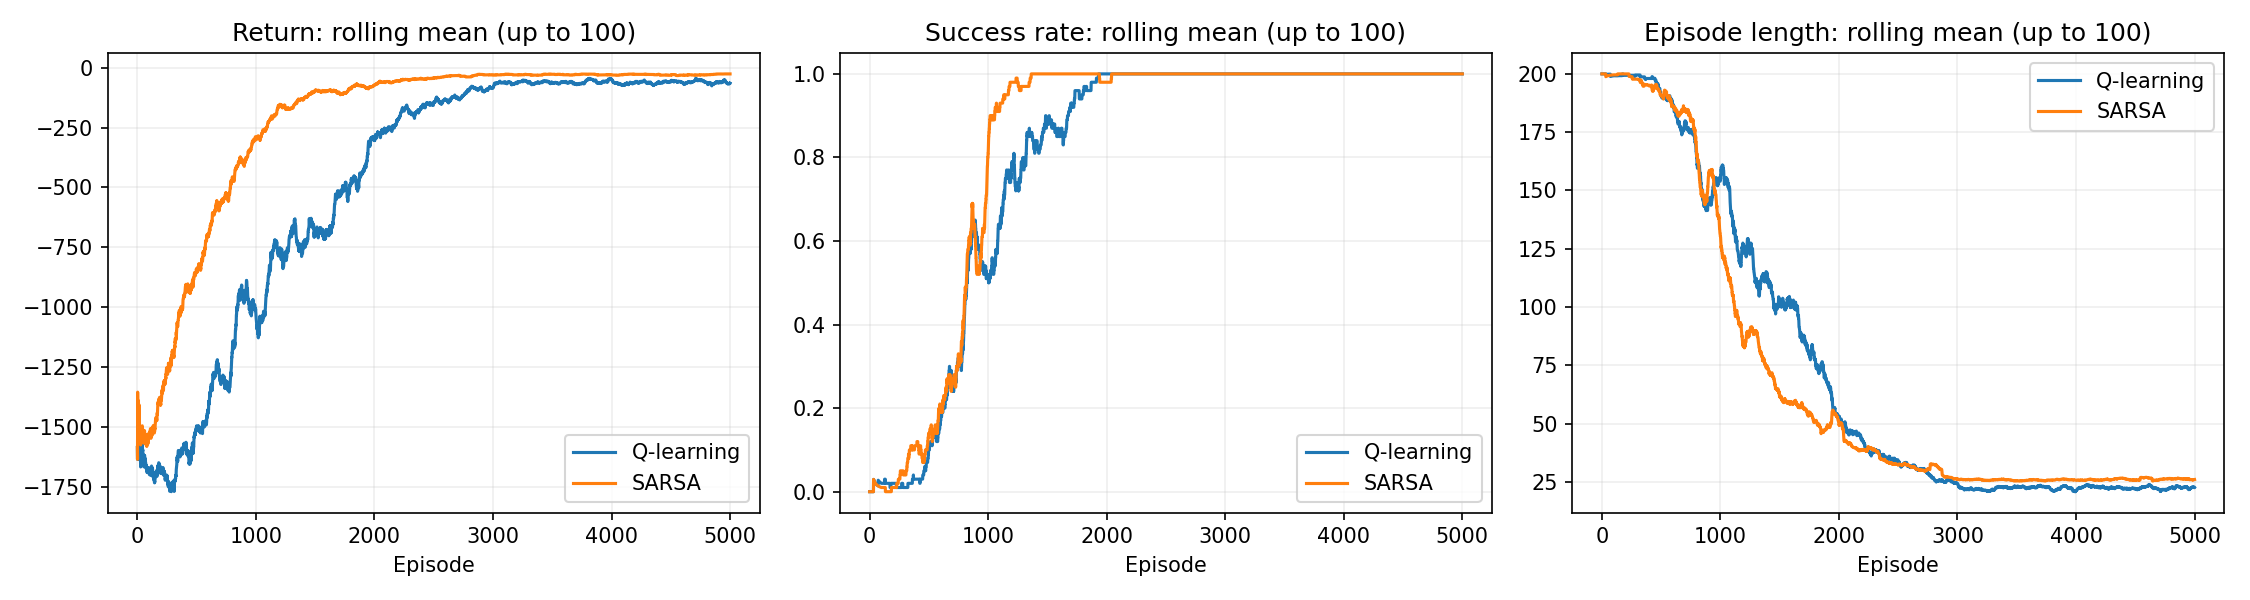

Saved comparison: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\comparison\20260915T145155746078Z_seed0_a6ed1147\plots\cliff_qlearning_vs_sarsa.png


In [6]:
comparison_result = None
if all(algorithm in results for algorithm in ("qlearning", "sarsa")):
    if COMPARISON_WINDOW < 1:
        raise ValueError("COMPARISON_WINDOW must be positive")
    comparison = Run(
        "cliff", "comparison", SEED,
        {"kind": "comparison", "source_runs": {a: str(r.run_dir) for a, r in results.items()},
         "window": COMPARISON_WINDOW}, OUTPUT_ROOT,
    )
    try:
        comparison_path = comparison.path / "plots/cliff_qlearning_vs_sarsa.png"
        plot_comparison(results["qlearning"], results["sarsa"], comparison_path, window=COMPARISON_WINDOW)
        comparison_result = comparison.finish()
    except BaseException:
        comparison.finish("failed")
        raise
    display(Image(filename=str(comparison_path)))
    print(f"Saved comparison: {comparison_path}")
else:
    print("Comparison unavailable: train both Q-learning and SARSA in this execution.")

## Evaluation and report export

Open [eval_grid_cliff.ipynb](eval_grid_cliff.ipynb) to evaluate selected checkpoints greedily and save presentation recordings.

For the report, review the completed comparison and copy `plots/cliff_qlearning_vs_sarsa.png` into the report figure directory. Update the matching report analysis using the saved metrics. [The report figure inventory](../Report/figures/README.md) identifies the pending slots. This notebook does not replace report evidence automatically.

### NEW ROBA PER CONFIDENZE

In [7]:
def latest_run_dir(environment, algorithm, output_root=OUTPUT_ROOT):
    base = Path(output_root) / environment / algorithm
    candidates = [p for p in base.iterdir() if p.is_dir() and (p / "metrics.csv").exists()]
    if not candidates:
        raise FileNotFoundError(f"Nessuna run trovata in {base}")
    return sorted(candidates, key=lambda p: p.name)[-1]

run_dirs = {
    "qlearning": latest_run_dir("cliff", "qlearning"),
    "sarsa": latest_run_dir("cliff", "sarsa"),
}
for algo, d in run_dirs.items():
    print(f"{ALGORITHM_LABELS[algo]}: {d}")

Q-learning: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\qlearning\20260915T145107708840Z_seed0_630db017
SARSA: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\sarsa\20260915T145132670752Z_seed0_df131c78


In [8]:
import pandas as pd

def bootstrap_band(values, window=100, n_boot=300, ci=95, seed=0):
    """Bootstrap CI on a rolling window, from metrics.csv already on disk. No retraining."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = np.full(n, np.nan)
    lo = np.full(n, np.nan)
    hi = np.full(n, np.nan)
    for i in range(window, n):
        w = values[i - window:i]
        idx = rng.integers(0, window, size=(n_boot, window))
        boot_means = w[idx].mean(axis=1)
        mean[i] = w.mean()
        lo[i], hi[i] = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return mean, lo, hi

def load_metrics(run_dir):
    df = pd.read_csv(Path(run_dir) / "metrics.csv")
    # "episode" in metrics.csv counts completed episodes from 1 (see runtime.Run.append).
    df = df.sort_values("episode").reset_index(drop=True)
    return df

In [12]:
import matplotlib.pyplot as plt
import numpy as np

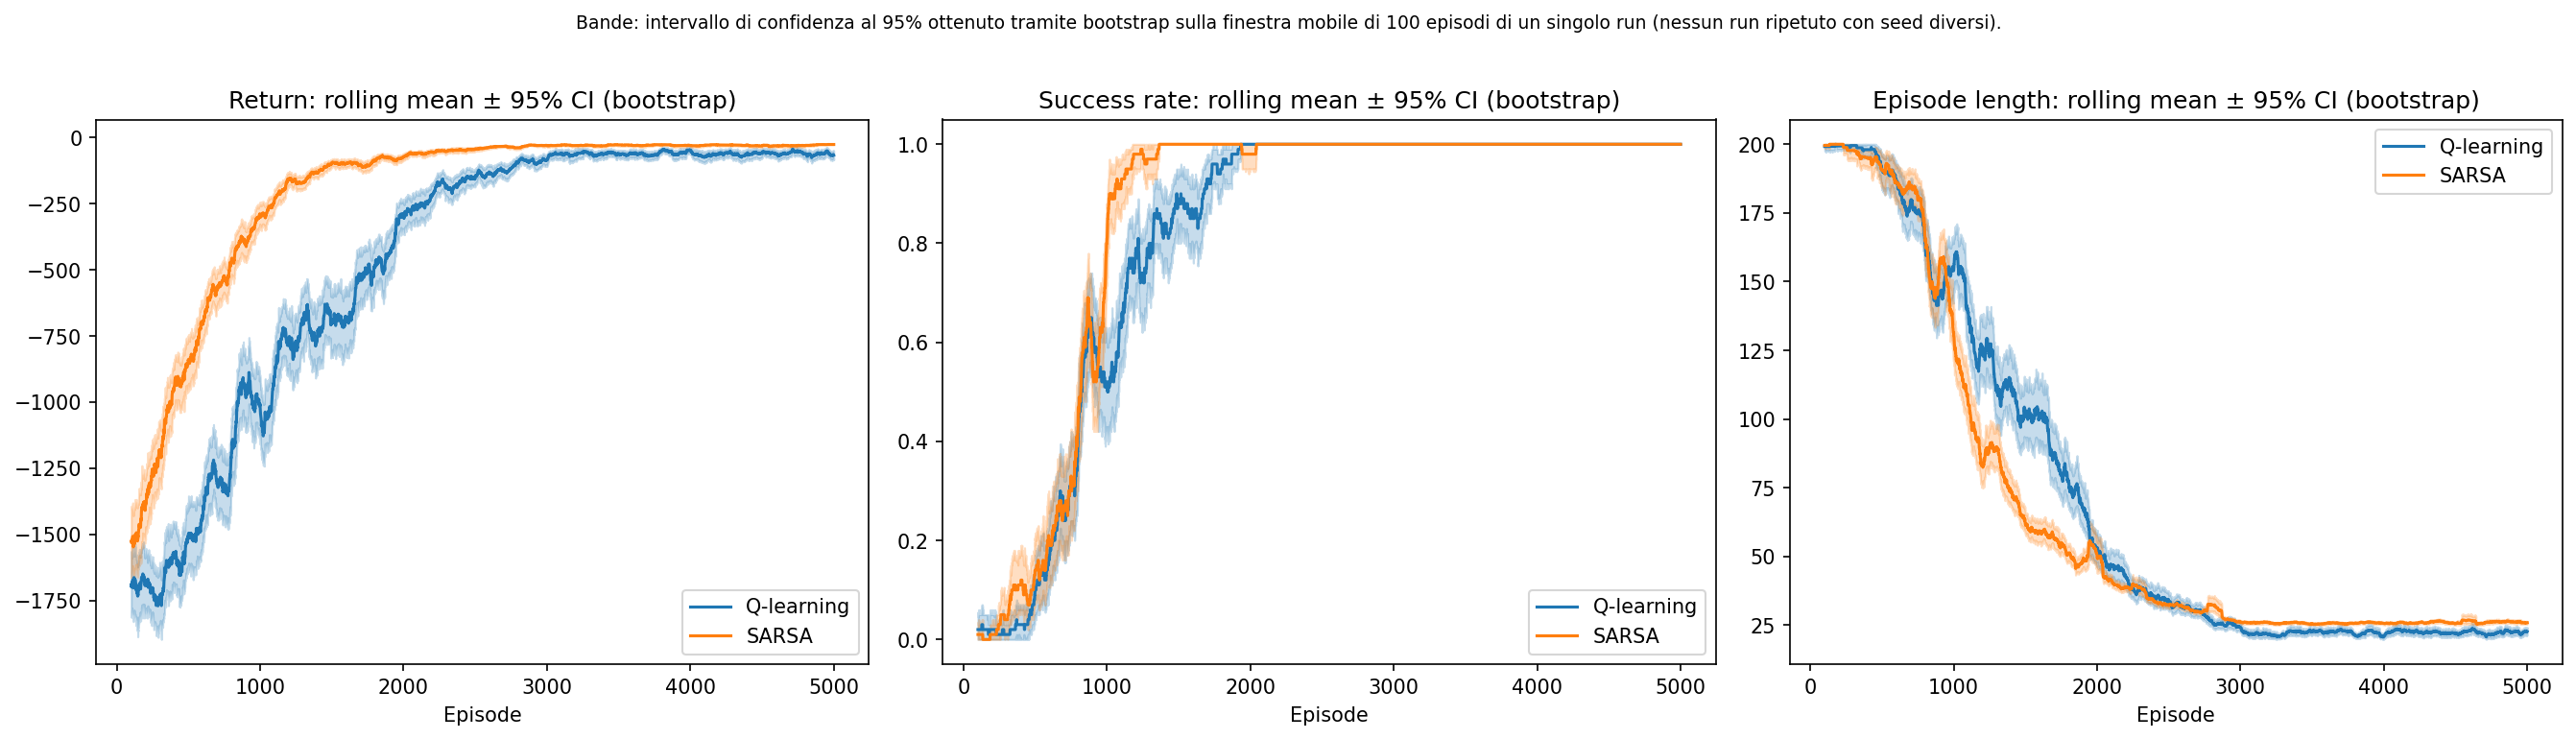

Salvato: c:\Users\39324\Desktop\NAML_RL_gym\artifacts\cliff\comparison_bootstrap\cliff_qlearning_vs_sarsa_bootstrap.png


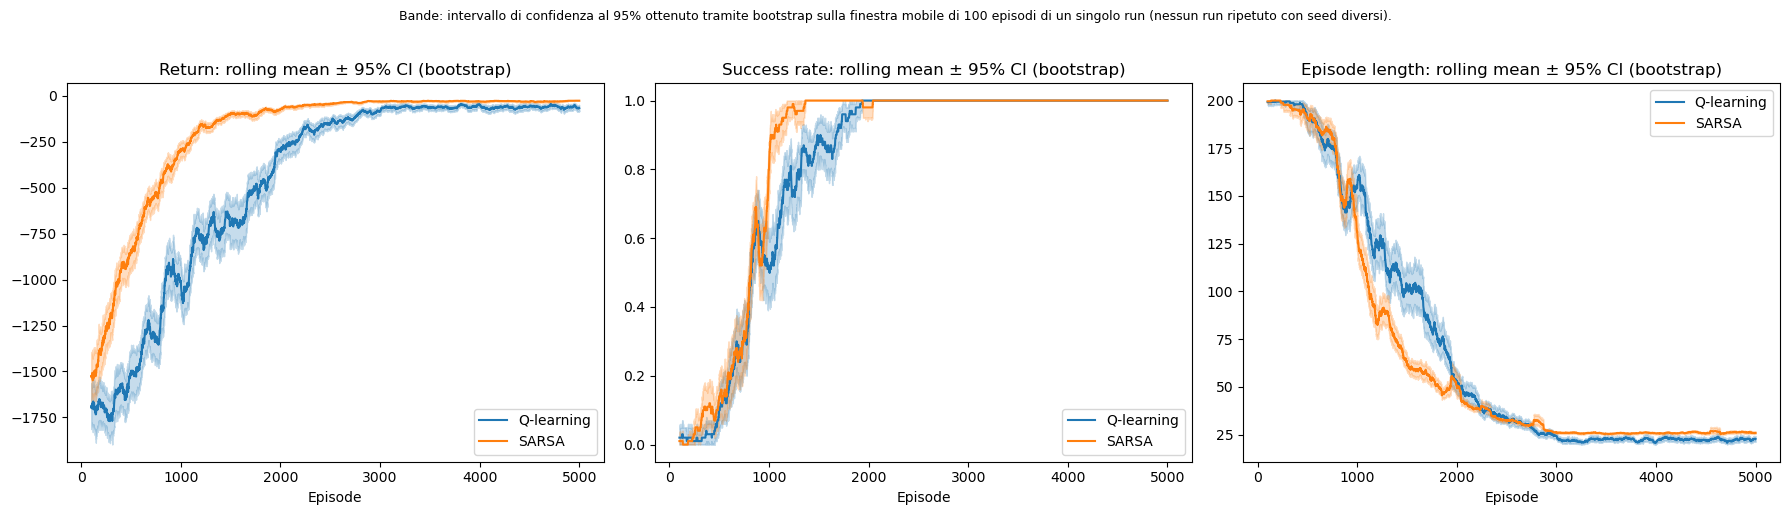

In [14]:
algo_colors = {"qlearning": "tab:blue", "sarsa": "tab:orange"}
panels = [("reward", "Return: rolling mean ± 95% CI (bootstrap)"),
          ("success", "Success rate: rolling mean ± 95% CI (bootstrap)"),
          ("length", "Episode length: rolling mean ± 95% CI (bootstrap)")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for algorithm, run_dir in run_dirs.items():
    df = load_metrics(run_dir)
    x = df["episode"].to_numpy()
    for (key, title), ax in zip(panels, axes):
        mean, lo, hi = bootstrap_band(df[key].to_numpy(), window=COMPARISON_WINDOW, n_boot=300)
        ax.plot(x, mean, label=ALGORITHM_LABELS[algorithm], color=algo_colors[algorithm])
        ax.fill_between(x, lo, hi, color=algo_colors[algorithm], alpha=0.25)

for (key, title), ax in zip(panels, axes):
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.legend()
fig.suptitle(
    "Bande: intervallo di confidenza al 95% ottenuto tramite bootstrap sulla finestra mobile "
    f"di {COMPARISON_WINDOW} episodi di un singolo run (nessun run ripetuto con seed diversi).",
    fontsize=9, y=1.02
)
fig.tight_layout()

bootstrap_path = run_dirs["qlearning"].parent.parent / "comparison_bootstrap" / "cliff_qlearning_vs_sarsa_bootstrap.png"
bootstrap_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(bootstrap_path, dpi=150, bbox_inches="tight")
display(Image(filename=str(bootstrap_path)))
print(f"Salvato: {bootstrap_path}")